# 03 Label construction

**Purpose:** build the targets the models will learn from. Neither Task 1 target is given directly, so we derive them from the route legs. Task 2A also needs a weekly demand table built to Waypoint's counting rules.

**Inputs:** clean tables from notebook 02 (`data/processed/`).

**Outputs** (in `data/processed/`):
- `stops.parquet`: one row per dispatched order (train and test) joined to its route leg, with the two Task 1 labels filled in for train
- `weekly_demand.parquet`: weekly total and chilled volume per depot and brand, ready for Task 2A

**The labels in one line each**
- `service_min` = time the vehicle leaves the outlet minus the later of its arrival and the window opening
- `late` = 1 if the vehicle arrives after the window closes, else 0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora.io import load_processed, save_processed
from xora.plotting import apply_style, SERIES
from xora import checks as ck

apply_style()
pd.set_option("display.width", 160)

orders = load_processed("orders")
legs = load_processed("legs")
outlets = load_processed("outlets")
calendar = load_processed("calendar")
allowance = load_processed("service_allowance")

## 1. One row per delivered order

Notebook 01 showed that every dispatched order, deferred ones included, has exactly one route leg. We join on route and stop position, and keep only the leg columns the labels and later features need.

In [2]:
LEG_COLS = [
    "route_id", "seq", "leg_id", "date", "from_point", "distance_km", "dow", "monsoon",
    "planned_depart_time_min", "planned_travel_duration_min", "planned_arrival_time_min",
    "actual_depart_time_min", "actual_travel_duration_min", "arrival_time_min", "leave_outlet_time_min",
]

dispatched = orders[orders.route_id.notna()]
stops = dispatched.merge(
    legs[LEG_COLS], left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"],
    how="left", validate="one_to_one",
).merge(outlets[["outlet_id", "dock_type", "parking_constraint"]], on="outlet_id", how="left", validate="many_to_one")

stops.groupby("split").size().rename("stops").to_frame()

,stops
split,
test,5014
train,91894


`validate="one_to_one"` makes pandas raise an error if any order matched more than one leg, so the join is checked by construction. The `not_run` orders drop out here because they never had a route. They come back in section 5 for the demand table.

## 2. Service time label

**Why not simply leave time minus arrival time?** Waypoint's rules say outlets receive goods only within their window and early arrivals wait until it opens. Time spent waiting outside a closed outlet is not handling time. So service starts at whichever comes later: the arrival or the window opening.

```
service_start = max(arrival_time, window_open_time)
service_min   = leave_outlet_time - service_start
wait_min      = service_start - arrival_time      (0 when the vehicle arrives inside the window)
```

In [3]:
train = stops.split == "train"

service_start = np.maximum(stops.arrival_time_min, stops.window_open_time_min)
stops["wait_min"] = (service_start - stops.arrival_time_min).where(train)
stops["service_min"] = (stops.leave_outlet_time_min - service_start).where(train)
stops["dwell_min"] = (stops.leave_outlet_time_min - stops.arrival_time_min).where(train)

stops.loc[train, ["dwell_min", "wait_min", "service_min"]].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
dwell_min,91894.0,19.9,15.7,2.0,11.0,16.0,23.0,428.0
wait_min,91894.0,0.9,5.7,0.0,0.0,0.0,0.0,132.0
service_min,91894.0,19.0,14.9,2.0,11.0,15.0,22.0,428.0


In [4]:
waited = stops.loc[train & (stops.wait_min > 0)]
pd.Series({
    "stops that waited for the window": len(waited),
    "share of all stops": round(len(waited) / train.sum(), 3),
    "median wait when waiting (min)": waited.wait_min.median(),
    "share of waits on the first stop": round((waited.seq == 0).mean(), 3),
})

stops that waited for the window    4023.000
share of all stops                     0.044
median wait when waiting (min)        14.000
share of waits on the first stop       0.730
dtype: float64

Waiting is rare overall but concentrated on first stops, where a truck that left the depot early reaches an outlet before it opens. Using leave minus arrival would have inflated exactly those labels and taught the model that first stops are slow.

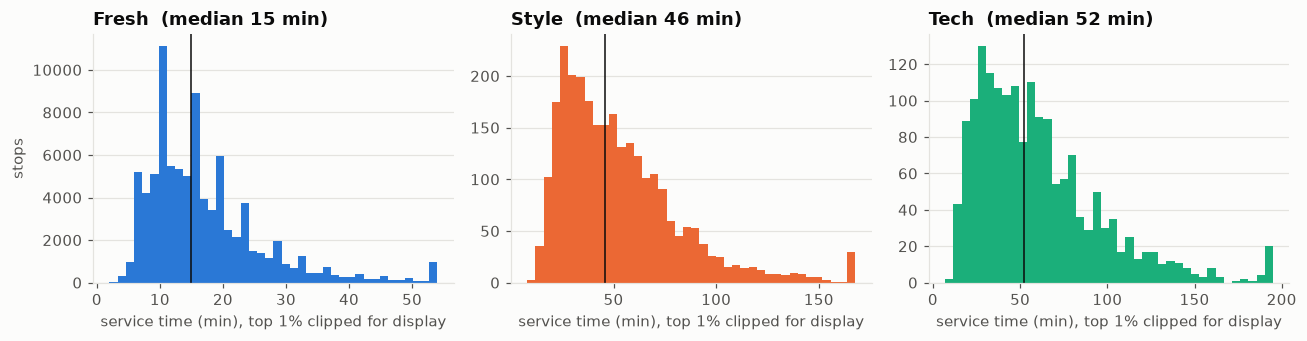

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, brand, color in zip(axes, ["Fresh", "Style", "Tech"], SERIES):
    s = stops.loc[train & (stops.brand == brand), "service_min"]
    ax.hist(s.clip(upper=s.quantile(0.99)), bins=40, color=color)
    ax.axvline(s.median(), color="#0b0b0b", linewidth=1)
    ax.set_title(f"{brand}  (median {s.median():.0f} min)")
    ax.set_xlabel("service time (min), top 1% clipped for display")
axes[0].set_ylabel("stops")
plt.tight_layout()
plt.show()

In [6]:
stops.loc[train].pivot_table(index="brand", columns="dock_type", values="service_min", aggfunc="median")

dock_type,mall_bay,rear_dock,street
brand,,,
Fresh,NaN,15.0,14.0
Style,61.0,30.0,45.0
Tech,74.0,35.0,67.0


Service time differs a lot by brand and by how goods come off the truck: rear docks are quickest, and mall bays are slowest for Style and Tech. The distributions are right-skewed, with a long tail of slow stops. Those are kept, as explained in notebook 02.

## 3. Late label

Waypoint defines late as arriving after `window_close_time`. Late deliveries are still made, so this label is about arrival only, not about whether the order was delivered.

```
late = 1 if arrival_time > window_close_time else 0
```

Arriving exactly at closing time counts as on time, because the operating rules say "after".

In [7]:
stops["late"] = (stops.arrival_time_min > stops.window_close_time_min).astype("Int8").where(train)
stops["late_by_min"] = (stops.arrival_time_min - stops.window_close_time_min).clip(lower=0).where(train)

pd.Series({
    "late rate": stops.loc[train, "late"].mean().round(3),
    "arrivals exactly at closing time (counted on time)": int((stops.arrival_time_min == stops.window_close_time_min)[train].sum()),
    "median minutes late, when late": stops.loc[train & (stops.late == 1), "late_by_min"].median(),
})

late rate                                               0.196
arrivals exactly at closing time (counted on time)    279.000
median minutes late, when late                         48.000
dtype: float64

In [8]:
stops.loc[train].groupby(["brand", "depot"]).late.agg(late_rate="mean", stops="size").round(3)

late_rate  stops
brand depot                       
Fresh Kandy           0.202  34039
      Peliyagoda      0.205  53418
Style Kandy           0.035    977
      Peliyagoda      0.066   1756
Tech  Kandy           0.064    593
      Peliyagoda      0.004   1111

About one stop in five arrives late, mostly Fresh, where the window closes around 8 AM and routes are long. Classes are imbalanced but not extreme, so a plain probability model with good calibration is appropriate. No resampling is needed.